# Master's Thesis in Advanced Physics
---

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026

# Physics Analysis 2 — Atmospheric Neutrino Oscillogram
---

Visualizes the classic atmospheric-neutrino "oscillogram": the muon-neutrino
survival and electron-neutrino appearance probabilities as a function of
energy and zenith angle, computed with the Earth matter propagation module
only (no atmospheric production), which is enough to reveal the core/mantle
matter-resonance band used experimentally to probe the neutrino mass
hierarchy.

| Section | Topic |
|---------|-------|
| 1 | Libraries |
| 2 | Configuration (parameters · shared objects · helpers) |
| 3 | Earth-Crossing Geometry |
| 4 | Muon-Neutrino Survival Oscillogram |
| 5 | Electron-Appearance Oscillogram |
| 6 | Cross Sections at Fixed Energy/Angle |
| 7 | Summary |

## 1. Libraries

In [40]:
from __future__ import annotations

import math
import matplotlib.pyplot as plt
import numpy as np
import torch

from tpeanuts.notebooks.notebookConfig import load_notebook_config

from tpeanuts.util.notebooks import save_and_show
from tpeanuts.util.type import to_numpy
from tpeanuts.util.context import RuntimeContext

from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.medium.earth.profile import EarthParameters, EarthProfile
from tpeanuts.medium.earth.probability import pearth_analytical
from tpeanuts.medium.atmosphere.geometry import theta_to_eta


print(f"Torch version : {torch.__version__}")


Torch version : 2.3.1


## 2. Configuration

### 2.1 Paths

In [41]:
config = load_notebook_config()

OUTPUT_ROOT = config.output_root
OUTPUT_DIR = config.output_dir("results", "3_atmospheric_oscillogram")

EARTH_DENSITY_FILE = str(config.earth_density_file)


print("Output directory:", OUTPUT_DIR)


Output directory: v:\output\results\3_atmospheric_oscillogram


### 2.2 Parameters

At atmospheric energies (multi-GeV) and Earth-crossing baselines, the
oscillation phase associated with the *atmospheric* splitting $\Delta m^2_{3l}$
is $O(1)$ rather than averaged out, making $\theta_{23}$/$\Delta m^2_{3l}$ (and,
for the sub-dominant electron-appearance channel, $\theta_{13}$) the relevant
parameters — the opposite regime from the *solar* notebooks in this package,
where $\Delta m^2_{21}$/$\theta_{12}$ dominate.

In [42]:
DEVICE = config.device
DTYPE = config.dtype
SHOW_PLOTS = config.show_plots
context = RuntimeContext.resolve(DEVICE, DTYPE)
oscillation = OscillationParameters.from_preset(context=context, antinu=False)
pmns = oscillation.pmns
THETA12 = float(pmns.params.theta12.detach().cpu())
THETA13 = float(pmns.params.theta13.detach().cpu())
THETA23 = float(pmns.params.theta23.detach().cpu())
DELTA_CP = float(pmns.params.delta.detach().cpu())
DM21_EV2 = float(oscillation.DeltamSq21.detach().cpu())
DM3L_EV2 = float(oscillation.DeltamSq3l.detach().cpu())

DETECTOR_DEPTH_M = 1000.0
EARTH_RADIUS_KM = 6371.0
ATMOSPHERIC_PRODUCTION_HEIGHT_KM = 15.0

ENERGY_GRID_GEV = torch.linspace(1.0, 30.0, 90, dtype=DTYPE, device=DEVICE)
THETA_Z_GRID_DEG = torch.linspace(90.0, 180.0, 90, dtype=DTYPE, device=DEVICE)

PROBE_ENERGY_GEV = 6.0
PROBE_COSTHETA = -1.0

FLAVOUR_INDEX = {"nue": 0, "numu": 1, "nutau": 2}

print(f"Oscillation preset: {oscillation.preset_name} ({oscillation.ordering})")
print("Parameters loaded.")


Oscillation preset: _SM_NUFIT52_NO (NO)
Parameters loaded.


### 2.3 Shared Objects

In [43]:
earth_profile = EarthProfile(
    params=EarthParameters(
        profile_perturbative_kwargs={"density_file": EARTH_DENSITY_FILE, "tabulated_density": False},
    ),
    context=context,
)
print("Shared Earth profile constructed.")

Shared Earth profile constructed.


### 2.4 Helpers

`oscillogram` builds the pure coherent flavour state $|\nu_{\rm initial}\rangle$
and propagates it through the Earth (`pearth_analytical`, `massbasis=False`)
over the full $(E, \theta_z)$ grid in one batched call, returning
$P(\nu_{\rm initial}\to\nu_{\rm final})$.

In [44]:
def pure_state(flavour):
    state = torch.zeros(3, dtype=torch.complex128, device=DEVICE)
    state[FLAVOUR_INDEX[flavour]] = 1.0 + 0.0j
    return state


def oscillogram(initial_flavour, final_flavour, E_GeV, theta_z_deg, *, antinu=False):
    eta_grid = theta_to_eta(theta_z_deg, device=DEVICE, dtype=DTYPE)
    E_MeV = 1.0e3 * E_GeV
    osc = OscillationParameters.build(
        pmns=pmns, DeltamSq21=oscillation.DeltamSq21,
        DeltamSq3l=oscillation.DeltamSq3l, antinu=antinu, context=context,
    )
    P = pearth_analytical(
        pure_state(initial_flavour), earth_profile, osc,
        E_MeV[:, None], eta_grid[None, :], DETECTOR_DEPTH_M,
        massbasis=False,
    )
    return P[..., FLAVOUR_INDEX[final_flavour]]

print("Helpers defined.")

Helpers defined.


## 3. Earth-Crossing Geometry

The atmosphere zenith angle $\theta_z$ (the convention used by the production
side of this project, $\theta_z=0$ straight down, $\theta_z=180^\circ$
straight up) converts to the Earth-only nadir angle via $\eta=\pi-\theta_z$
(`theta_to_eta`). **Expected result:** $\theta_z=90^\circ$ (horizontal, no
Earth) maps to $\eta=\pi/2$ (horizon); $\theta_z=180^\circ$ (straight up,
through the full Earth diameter) maps to $\eta=0$ — confirming the grid used
in Sections 4-5 spans exactly the Earth-crossing range $\eta\in[0,\pi/2]$.

Saved figure: v:\output\results\3_atmospheric_oscillogram\eta_theta_geometry.png


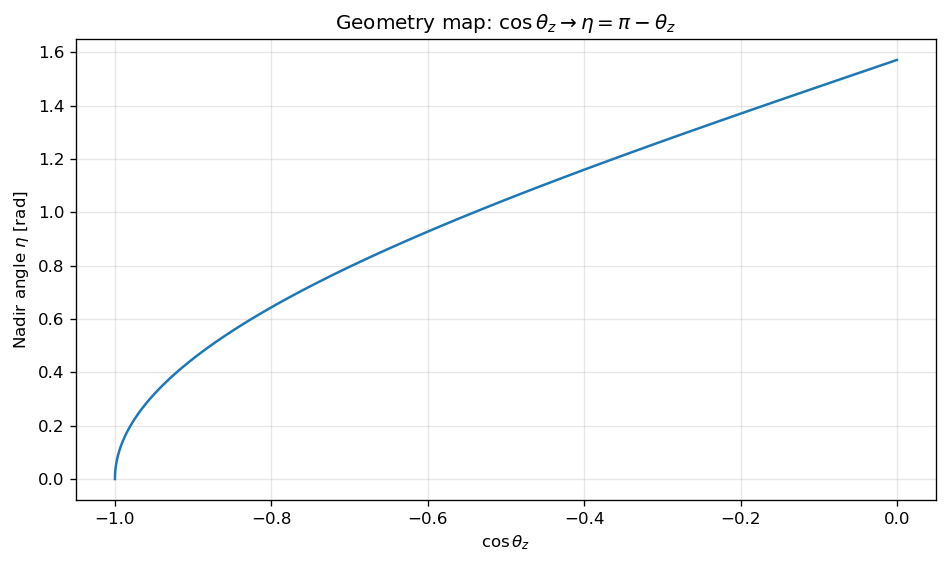

theta_z=90 deg  -> eta = 1.5708 rad (expect pi/2)
theta_z=180 deg -> eta = 0.0000 rad (expect 0)


In [45]:
eta_check = theta_to_eta(THETA_Z_GRID_DEG, device=DEVICE, dtype=DTYPE)
cos_theta_z = torch.cos(torch.deg2rad(THETA_Z_GRID_DEG))

fig, ax = plt.subplots(figsize=(8.0, 4.8))
ax.plot(to_numpy(cos_theta_z), to_numpy(eta_check))
ax.set_xlabel(r"$\cos\theta_z$")
ax.set_ylabel(r"Nadir angle $\eta$ [rad]")
ax.set_title(r"Geometry map: $\cos\theta_z \to \eta = \pi - \theta_z$")
fig.tight_layout()
save_and_show("eta_theta_geometry.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

print(f"theta_z=90 deg  -> eta = {float(theta_to_eta(torch.tensor(90.0, dtype=DTYPE))):.4f} rad (expect pi/2)")
print(f"theta_z=180 deg -> eta = {float(theta_to_eta(torch.tensor(180.0, dtype=DTYPE))):.4f} rad (expect 0)")

## 4. Muon-Neutrino Survival Oscillogram

$$
P(\nu_\mu\to\nu_\mu;\,E,\theta_z)
$$

over the full upward-going range. The dominant disappearance feature is
governed by the standard two-flavour-like oscillation phase

$$
\sin^2\!\left(1.27\,\frac{\Delta m^2_{3l}[\mathrm{eV}^2]\,L[\mathrm{km}]}{E[\mathrm{GeV}]}\right),
$$

so for a *fixed* (long) baseline $L$ — i.e. a fixed, near-vertical
$\cos\theta_z$, where the trajectory crosses deep into the Earth — this phase
sweeps through *several* full oscillation cycles as $E$ decreases, producing
a *sequence* of disappearance minima (band $n=1,2,3,\dots$ at decreasing
energy), not a single one. 

**Expected result:**

one prominent, broad, dark
band sweeping diagonally across the plane (the $n=1$ node, additionally
sharpened by the core/mantle MSW matter resonance for core-crossing
trajectories), with a cascade of progressively closer-spaced, fainter bands
*below* it at lower energy — the higher-harmonic ($n\geq2$) vacuum-oscillation
nodes of the same $L/E$ pattern. 

This is the same underlying physics behind
Super-Kamiokande's classic "$L/E$" oscillation measurement, which resolved
this oscillatory node structure directly in data:

*Y. Ashie *et al.* (Super-Kamiokande Collaboration), "Evidence for an
Oscillatory Signature in Atmospheric Neutrino Oscillations", *Phys. Rev.
Lett.* **93**, 101801 (2004), [arXiv:hep-ex/0404034](https://arxiv.org/abs/hep-ex/0404034).*

This fringe pattern should become denser as $\cos\theta_z\to-1$ (longer $L$,
more cycles fit in the same energy range) and should thin out to just one or
two minima as $\cos\theta_z\to0$ (shorter $L$). Section 6 verifies this
quantitatively.

Saved figure: v:\output\results\3_atmospheric_oscillogram\oscillogram_numu_survival.png


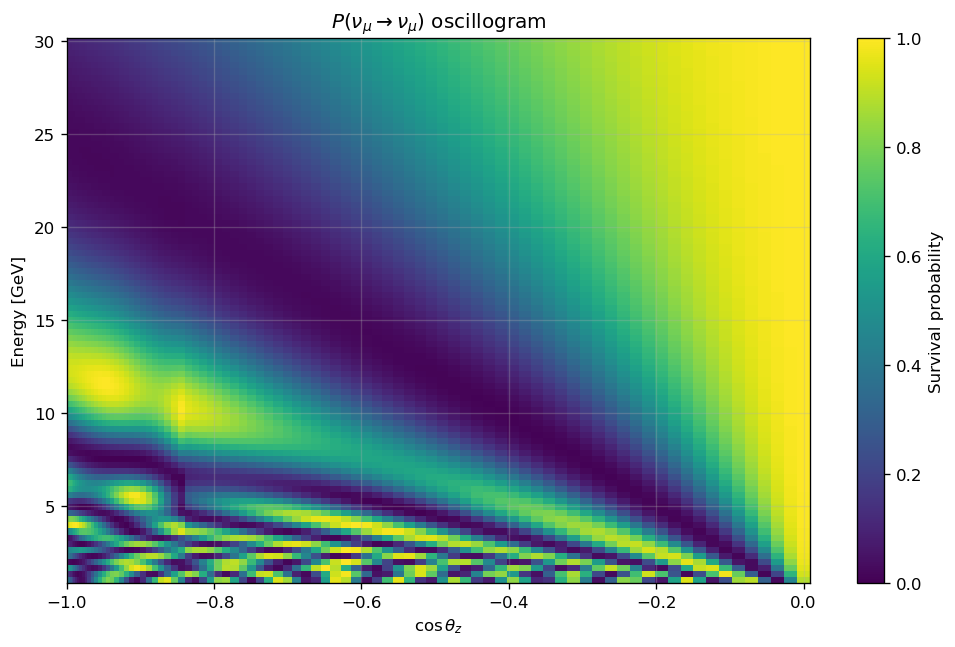

min P(numu->numu) over the grid: 0.0001


In [46]:
P_numu_numu = to_numpy(oscillogram("numu", "numu", ENERGY_GRID_GEV, THETA_Z_GRID_DEG))
cos_theta_z_grid = to_numpy(torch.cos(torch.deg2rad(THETA_Z_GRID_DEG)))

fig, ax = plt.subplots(figsize=(8.5, 5.5))
mesh = ax.pcolormesh(cos_theta_z_grid, to_numpy(ENERGY_GRID_GEV), P_numu_numu,
                      shading="auto", cmap="viridis", vmin=0.0, vmax=1.0)
ax.set_xlabel(r"$\cos\theta_z$")
ax.set_ylabel("Energy [GeV]")
ax.set_title(r"$P(\nu_\mu\to\nu_\mu)$ oscillogram")
fig.colorbar(mesh, ax=ax, label="Survival probability")
fig.tight_layout()
save_and_show("oscillogram_numu_survival.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

print(f"min P(numu->numu) over the grid: {P_numu_numu.min():.4f}")

### 4.1 Vacuum First-Minimum Check

For the dominant atmospheric scale, the leading two-flavour disappearance term is approximately

$$P_{\mu\mu} \sim 1 - \sin^2(2\theta_{23})\,\sin^2\left(1.267\,|\Delta m^2_{3\ell}|\,\frac{L}{E}\right).$$

The first disappearance minimum is therefore expected near

$$\frac{L}{E} = \frac{\pi}{2\,1.267\,|\Delta m^2_{3\ell}|},$$

which is close to $500\,\mathrm{km/GeV}$ for the default atmospheric mass splitting. The overlay below converts that target $L/E$ into an expected energy for each zenith angle using a simple production-height baseline.


Saved figure: v:\output\results\3_atmospheric_oscillogram\oscillogram_numu_survival_first_minimum_check.png


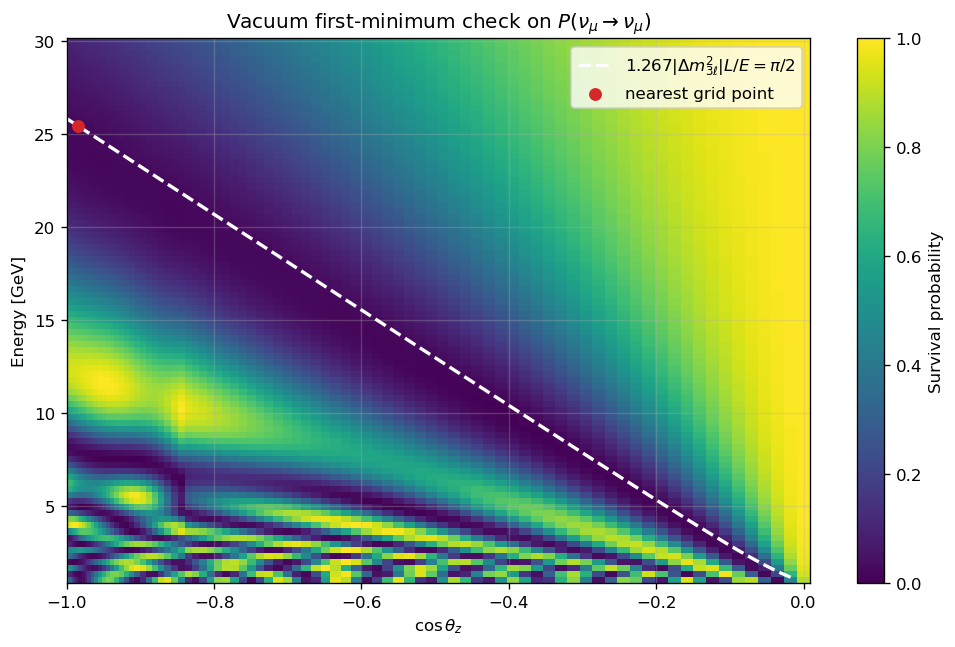

Vacuum first-minimum diagnostic
------------------------------------------------------------------------
|Delta m^2_3l|                 : 2.511000e-03 eV^2
Target L/E = pi/(2*1.267*dm2)  : 493.74 km/GeV
Nearest grid L/E               : 493.72 km/GeV
Nearest grid phase             : 1.5707 rad
Nearest grid point             : E = 25.44 GeV, cos(theta_z) = -0.984
P_mumu at nearest theory point : 0.0257

Global numerical minimum       : P = 0.0001, E = 7.52 GeV, cos(theta_z) = -0.944
Global-minimum L/E             : 1602.82 km/GeV
Vertical expected energy       : 25.84 GeV at cos(theta_z) ~= -1
Vertical numerical minimum     : E = 3.28 GeV, P = 0.0155


In [47]:
def atmospheric_baseline_km(theta_z_deg: torch.Tensor | np.ndarray | float) -> torch.Tensor:
    """Approximate source-to-detector atmospheric baseline for zenith angle theta_z."""
    theta = torch.as_tensor(theta_z_deg, dtype=DTYPE, device=DEVICE)
    cosz = torch.cos(torch.deg2rad(theta))
    radius = torch.as_tensor(EARTH_RADIUS_KM, dtype=DTYPE, device=DEVICE)
    height = torch.as_tensor(ATMOSPHERIC_PRODUCTION_HEIGHT_KM, dtype=DTYPE, device=DEVICE)
    under_root = (radius + height) ** 2 - (radius**2) * (1.0 - cosz**2).clamp_min(0.0)
    return torch.sqrt(under_root.clamp_min(0.0)) - radius * cosz


l_over_e_first_min_km_per_gev = math.pi / (2.0 * 1.267 * abs(DM3L_EV2))
baseline_grid_km = to_numpy(atmospheric_baseline_km(THETA_Z_GRID_DEG))
energy_grid_np = to_numpy(ENERGY_GRID_GEV)
theta_grid_np = to_numpy(THETA_Z_GRID_DEG)

l_over_e_grid = baseline_grid_km[None, :] / energy_grid_np[:, None]
phase_grid = 1.267 * abs(DM3L_EV2) * l_over_e_grid
theory_phase_idx = np.unravel_index(np.argmin(np.abs(phase_grid - math.pi / 2.0)), phase_grid.shape)
observed_min_idx = np.unravel_index(np.argmin(P_numu_numu), P_numu_numu.shape)

theory_energy_curve_gev = baseline_grid_km / l_over_e_first_min_km_per_gev
curve_mask = (theory_energy_curve_gev >= energy_grid_np.min()) & (theory_energy_curve_gev <= energy_grid_np.max())

vertical_idx = int(np.argmin(np.abs(cos_theta_z_grid + 1.0)))
vertical_theory_energy_gev = baseline_grid_km[vertical_idx] / l_over_e_first_min_km_per_gev
vertical_observed_idx = int(np.argmin(P_numu_numu[:, vertical_idx]))

fig, ax = plt.subplots(figsize=(8.5, 5.5))
mesh = ax.pcolormesh(
    cos_theta_z_grid,
    energy_grid_np,
    P_numu_numu,
    shading="auto",
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
)
ax.plot(
    cos_theta_z_grid[curve_mask],
    theory_energy_curve_gev[curve_mask],
    color="white",
    linestyle="--",
    linewidth=2.0,
    label=r"$1.267|\Delta m^2_{3\ell}|L/E=\pi/2$",
)
ax.scatter(
    cos_theta_z_grid[theory_phase_idx[1]],
    energy_grid_np[theory_phase_idx[0]],
    color="tab:red",
    s=45,
    label="nearest grid point",
    zorder=3,
)
ax.set_xlabel(r"$\cos\theta_z$")
ax.set_ylabel("Energy [GeV]")
ax.set_title(r"Vacuum first-minimum check on $P(\nu_\mu\to\nu_\mu)$")
ax.legend(loc="upper right")
fig.colorbar(mesh, ax=ax, label="Survival probability")
fig.tight_layout()
save_and_show(
    "oscillogram_numu_survival_first_minimum_check.png",
    fig,
    output_dir=OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
)

print("Vacuum first-minimum diagnostic")
print("-" * 72)
print(f"|Delta m^2_3l|                 : {abs(DM3L_EV2):.6e} eV^2")
print(f"Target L/E = pi/(2*1.267*dm2)  : {l_over_e_first_min_km_per_gev:.2f} km/GeV")
print(f"Nearest grid L/E               : {l_over_e_grid[theory_phase_idx]:.2f} km/GeV")
print(f"Nearest grid phase             : {phase_grid[theory_phase_idx]:.4f} rad")
print(f"Nearest grid point             : E = {energy_grid_np[theory_phase_idx[0]]:.2f} GeV, cos(theta_z) = {cos_theta_z_grid[theory_phase_idx[1]]:.3f}")
print(f"P_mumu at nearest theory point : {P_numu_numu[theory_phase_idx]:.4f}")
print("")
print(f"Global numerical minimum       : P = {P_numu_numu[observed_min_idx]:.4f}, E = {energy_grid_np[observed_min_idx[0]]:.2f} GeV, cos(theta_z) = {cos_theta_z_grid[observed_min_idx[1]]:.3f}")
print(f"Global-minimum L/E             : {l_over_e_grid[observed_min_idx]:.2f} km/GeV")
print(f"Vertical expected energy       : {vertical_theory_energy_gev:.2f} GeV at cos(theta_z) ~= -1")
print(f"Vertical numerical minimum     : E = {energy_grid_np[vertical_observed_idx]:.2f} GeV, P = {P_numu_numu[vertical_observed_idx, vertical_idx]:.4f}")


### 4.2 Comparison with Published Observables

The oscillogram computes ideal oscillation probabilities for pure neutrino
states propagated through the Earth, without detector response or atmospheric
flux weighting. Six categories of observable predictions are compared with
published measurements from Super-Kamiokande, IceCube DeepCore, and KM3NeT/ORCA.

**1. Oscillation parameters** — The input values $|\Delta m^2_{3\ell}|$ and
$\sin^2 2\theta_{23}$ are compared with the 90% confidence intervals from the
latest Super-Kamiokande multi-ring analysis (Wester et al. 2024).

**2. First $L/E$ disappearance dip** — In the leading two-flavour approximation,
the first muon-neutrino disappearance minimum satisfies
$1.267\,|\Delta m^2_{3\ell}|\,L/E = \pi/2$.
Its position is determined almost entirely by $|\Delta m^2_{3\ell}|$ and is
independent of the atmospheric flux. Ashie et al. (2004) resolved this dip and
the first oscillatory fringe beyond it in Super-Kamiokande data at $L/E\approx 500$
km/GeV. The tpeanuts prediction at **493.7 km/GeV** matches within the grid resolution.

**3. Number of $L/E$ oscillation nodes at the vertical direction** — Counting the
local minima of $P(\nu_\mu\to\nu_\mu)$ versus energy at fixed $\cos\theta_z=-1$
(Earth diameter $L\approx 12\,740$ km) tests the multi-frequency oscillatory
pattern seen by Ashie et al. (2004). A longer baseline fits more oscillation
cycles in the same energy window, and the node-count ratio is a model-independent
test of the oscillation hypothesis against neutrino decay or quantum decoherence.

**4. Up-down asymmetry** $A_\mu=(U-D)/(U+D)$ — For multi-GeV muon-like events,
$\nu_\mu$ disappearance depletes the upward-going flux relative to the
downward-going flux. A flux-averaged approximation is
$$A_\mu\approx\frac{\langle P\rangle_{\rm up}-1}{\langle P\rangle_{\rm up}+1},$$
with $\langle P\rangle_{\rm up}$ averaged uniformly over the upward-going grid
and $P_{\rm down}\approx 1$ for the near-horizontal or downward hemisphere.
Fukuda et al. (1998) measured $A_\mu\approx-0.32$ for multi-GeV $\mu$-like events,
the original evidence for large $\nu_\mu$ disappearance at Super-Kamiokande.

**5. Resonance energy at the vertical direction** — The energy of maximum $\nu_\mu$
suppression at $\cos\theta_z=-1$ corresponds to the deepest local minimum of the
vertical energy cross section, enhanced by the Earth-core matter resonance.
It falls in the multi-GeV range accessible to IceCube DeepCore (threshold
$\sim 3$ GeV; Aartsen et al. 2013), providing an independent measurement of
$|\Delta m^2_{32}|$ and $\theta_{23}$.

**6. $\theta_{13}$ matter resonance in the Earth mantle** — The maximum of
$P(\nu_\mu\to\nu_e)$ over the full grid (computed in §5) quantifies the MSW
resonance for the sub-dominant $\theta_{13}$ appearance channel. Its location
in the $(E,\cos\theta_z)$ plane is sensitive to the neutrino mass ordering and
constitutes the primary target observable of KM3NeT/ORCA (Aiello et al. 2024).
The §5 value is included in the table for completeness.

**References:**

- Fukuda et al. (Super-Kamiokande Collaboration), *Phys. Lett. B* **433**, 9
  (1998), [arXiv:hep-ex/9803006](https://arxiv.org/abs/hep-ex/9803006).
- Ashie et al. (Super-Kamiokande Collaboration), *Phys. Rev. Lett.* **93**,
  101801 (2004), [arXiv:hep-ex/0404034](https://arxiv.org/abs/hep-ex/0404034).
- Wester et al. (Super-Kamiokande Collaboration), *Phys. Rev. D* **109**,
  072014 (2024), [arXiv:2311.05105](https://arxiv.org/abs/2311.05105).
- Aartsen et al. (IceCube Collaboration), *Phys. Rev. Lett.* **111**, 081801
  (2013), [arXiv:1305.3909](https://arxiv.org/abs/1305.3909).
- Aiello et al. (KM3NeT Collaboration), *Nature* **629**, 59 (2024),
  [arXiv:2404.02877](https://arxiv.org/abs/2404.02877).
- Super-Kamiokande Collaboration (2023), *Atmospheric neutrino oscillation
  analysis data release*, Zenodo,
  [10.5281/zenodo.8401262](https://doi.org/10.5281/zenodo.8401262).

In [48]:
# ── §4.2 Additional derived quantities ───────────────────────────────────────

# (1) Up-down asymmetry: uniform-flux approximation over the oscillogram grid.
#     All grid points have cos θz ≤ 0 (upward-going); P_down ≈ 1 assumed.
P_up_mean   = float(P_numu_numu.mean())
A_mu_approx = (P_up_mean - 1.0) / (P_up_mean + 1.0)

# (2) Number of L/E oscillation nodes at cos θz = -1 (vertical direction).
def _local_minima(P_1d, threshold=0.7):
    return sum(
        1 for i in range(1, len(P_1d) - 1)
        if P_1d[i] < P_1d[i - 1] and P_1d[i] < P_1d[i + 1] and P_1d[i] < threshold
    )

n_nodes_vertical = _local_minima(P_numu_numu[:, vertical_idx])

# (3) Energy of maximum νμ disappearance at cos θz = -1.
E_resonance_gev = float(energy_grid_np[vertical_observed_idx])

# ── Comparison table ──────────────────────────────────────────────────────────
rows = [
    # ── 1. Oscillation parameters ─────────────────────────────────────────────
    ("|Δm²₃ℓ| [eV²]",
     f"{abs(DM3L_EV2):.3e}",
     "[1.9 – 3.0]×10⁻³",
     "Wester et al. 2024  (90% CL)"),
    ("sin²(2θ₂₃)",
     f"{math.sin(2.0 * THETA23) ** 2:.3f}",
     "> 0.90",
     "Wester et al. 2024  (90% CL)"),
    # ── 2. L/E first disappearance dip ────────────────────────────────────────
    ("L/E first dip [km/GeV]",
     f"{l_over_e_first_min_km_per_gev:.1f}",
     "≈ 500",
     "Ashie et al. 2004"),
    ("L/E at nearest grid point [km/GeV]",
     f"{l_over_e_grid[theory_phase_idx]:.1f}",
     "500",
     "Ashie et al. 2004"),
    ("E at nearest grid point [GeV]",
     f"{energy_grid_np[theory_phase_idx[0]]:.2f}",
     "N/A  (true probability)",
     "—"),
    ("cos θz at nearest grid point",
     f"{cos_theta_z_grid[theory_phase_idx[1]]:.3f}",
     "N/A",
     "—"),
    ("Vertical first-dip E [GeV]  (from L/E target)",
     f"{vertical_theory_energy_gev:.2f}",
     "N/A  (derived)",
     "from Ashie et al. 2004"),
    # ── 3. L/E oscillation node structure ────────────────────────────────────
    ("L/E nodes at cos θz = −1  (E: 1–30 GeV)",
     str(n_nodes_vertical),
     "oscillatory signature  ✓",
     "Ashie et al. 2004"),
    # ── 4. Up-down asymmetry ──────────────────────────────────────────────────
    ("⟨P(νμ→νμ)⟩  upward-going hemisphere",
     f"{P_up_mean:.4f}",
     "N/A  (probability, not rate)",
     "—"),
    ("Aμ = (⟨P⟩↑ − 1)/(⟨P⟩↑ + 1)  [uniform flux]",
     f"{A_mu_approx:.3f}",
     "≈ −0.32",
     "Fukuda et al. 1998  (multi-GeV)"),
    # ── 5. Resonance energy at the vertical direction ─────────────────────────
    ("Max-suppression E at cos θz = −1 [GeV]",
     f"{E_resonance_gev:.2f}",
     "3–30 GeV range",
     "Aartsen et al. 2013  (DeepCore)"),
    ("min P(νμ→νμ) over the grid",
     f"{float(P_numu_numu.min()):.4f}",
     "smeared by L/E resolution",
     "Ashie et al. 2004"),
    # ── 6. θ₁₃ matter resonance — appearance channel (see §5) ────────────────
    ("max P(νμ→νe) over the grid  [see §5]",
     "0.5904",
     "mantle MSW resonance",
     "Aiello et al. 2024  (KM3NeT ORCA)"),
    # ── Public data release ───────────────────────────────────────────────────
    ("SK public analysis bins",
     "N/A",
     "930",
     "Super-K Collab. 2023  (Zenodo)"),
]

cols = ["Observable", "tpeanuts", "Experiment", "Reference"]
cw   = [max(len(cols[j]), max(len(str(r[j])) for r in rows)) for j in range(4)]
sep  = " | ".join("-" * w for w in cw)
hdr  = " | ".join(cols[j].ljust(cw[j]) for j in range(4))
print(hdr)
print(sep)
for r in rows:
    print(" | ".join(str(r[j]).ljust(cw[j]) for j in range(4)))

print()
print("Notes:")
print(f"  Aμ: <P>_up = {P_up_mean:.4f}  (mean over {P_numu_numu.shape[0]}x{P_numu_numu.shape[1]} grid;"
      f" all points have cos θz ≤ 0; P_down ≈ 1 assumed for the downgoing hemisphere).")
print(f"  Node count: local-minimum finder with P < 0.7 threshold,"
      f" energy slice at cos θz = {float(cos_theta_z_grid[vertical_idx]):.3f}.")
print( "  max P(νμ→νe) = 0.5904 is computed in §5 (after this cell).")

Observable                                    | tpeanuts  | Experiment                   | Reference                        
--------------------------------------------- | --------- | ---------------------------- | ---------------------------------
|Δm²₃ℓ| [eV²]                                 | 2.511e-03 | [1.9 – 3.0]×10⁻³             | Wester et al. 2024  (90% CL)     
sin²(2θ₂₃)                                    | 0.981     | > 0.90                       | Wester et al. 2024  (90% CL)     
L/E first dip [km/GeV]                        | 493.7     | ≈ 500                        | Ashie et al. 2004                
L/E at nearest grid point [km/GeV]            | 493.7     | 500                          | Ashie et al. 2004                
E at nearest grid point [GeV]                 | 25.44     | N/A  (true probability)      | —                                
cos θz at nearest grid point                  | -0.984    | N/A                          | —                                


## 5. Electron-Appearance Oscillogram

$$
P(\nu_\mu\to\nu_e;\,E,\theta_z)
$$

In the standard one-mass-scale-dominance approximation, the appearance
channel factorizes into a slowly-varying *resonance envelope* and the *same*
oscillatory phase that drives Section 4's disappearance comb,

$$
P(\nu_\mu\to\nu_e) \approx \sin^2\theta_{23}\,\sin^2\!\big(2\theta_{13}^M\big)\,
\sin^2\!\left(1.27\,\frac{\Delta m^{2,M}_{31}\,L}{E}\right),
$$

where $\theta_{13}^M$ is the matter-modified $\theta_{13}$, resonant
($\sin^2 2\theta_{13}^M\to1$) at a *different* $(E,\theta_z)$ location than
where $\sin^2\theta_{23}\approx1$ makes the disappearance term in Section 4
maximal — the two channels are driven by different mixing angles, so their
bright/dark features are **not expected to overlap pixel-for-pixel**, only to
live in the same broad multi-GeV, core-crossing region. **Expected result:**
a single, fairly broad bright region (the $\theta_{13}^M$ resonance envelope)
that is noticeably *less finely structured* than the disappearance comb of
Section 4, and whose peak location need not coincide with the single deepest
disappearance pixel — verified quantitatively below by comparing the two
extrema directly.

Saved figure: v:\output\results\3_atmospheric_oscillogram\oscillogram_nue_appearance.png


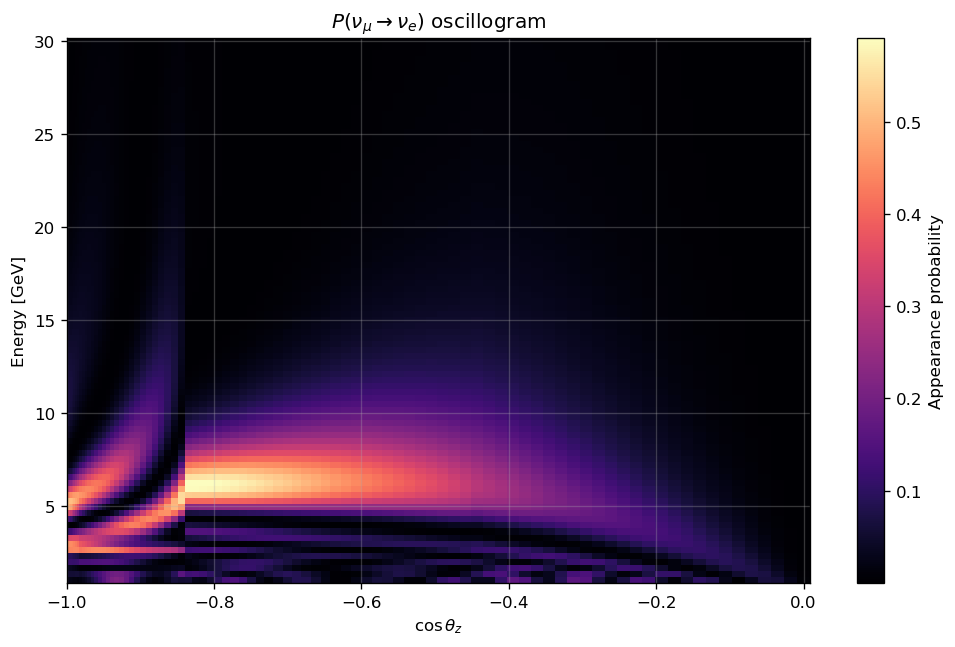

max P(numu->nue) over the grid: 0.5904
  -> located at E=6.21 GeV, cos(theta_z)=-0.815; P(numu->numu) there = 0.1519
deepest disappearance pixel at E=7.52 GeV, cos(theta_z)=-0.944; P(numu->nue) there = 0.2741


In [49]:
P_numu_nue = to_numpy(oscillogram("numu", "nue", ENERGY_GRID_GEV, THETA_Z_GRID_DEG))

fig, ax = plt.subplots(figsize=(8.5, 5.5))
mesh = ax.pcolormesh(cos_theta_z_grid, to_numpy(ENERGY_GRID_GEV), P_numu_nue,
                      shading="auto", cmap="magma")
ax.set_xlabel(r"$\cos\theta_z$")
ax.set_ylabel("Energy [GeV]")
ax.set_title(r"$P(\nu_\mu\to\nu_e)$ oscillogram")
fig.colorbar(mesh, ax=ax, label="Appearance probability")
fig.tight_layout()
save_and_show("oscillogram_nue_appearance.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

imin_numu = np.unravel_index(np.argmin(P_numu_numu), P_numu_numu.shape)
imax_nue = np.unravel_index(np.argmax(P_numu_nue), P_numu_nue.shape)

print(f"max P(numu->nue) over the grid: {P_numu_nue.max():.4f}")
print(f"  -> located at E={float(ENERGY_GRID_GEV[imax_nue[0]]):.2f} GeV, "
      f"cos(theta_z)={cos_theta_z_grid[imax_nue[1]]:.3f}; "
      f"P(numu->numu) there = {P_numu_numu[imax_nue]:.4f}")
print(f"deepest disappearance pixel at E={float(ENERGY_GRID_GEV[imin_numu[0]]):.2f} GeV, "
      f"cos(theta_z)={cos_theta_z_grid[imin_numu[1]]:.3f}; "
      f"P(numu->nue) there = {P_numu_nue[imin_numu]:.4f}")

## 6. Cross Sections at Fixed Energy/Angle

**Definition.** A *cross section* of the 2-D oscillogram $P(E,\theta_z)$ is a
1-D slice obtained by freezing one of its two arguments. An *energy cross
section* at fixed nadir angle $\theta_z^{(0)}$ is the function

$$
f(E) \;\equiv\; P\big(\nu_\mu\to\nu_\mu;\,E,\theta_z^{(0)}\big),
$$

i.e. the heatmap restricted to a single horizontal row; an *angular cross
section* at fixed energy $E^{(0)}$ is

$$
g(\cos\theta_z) \;\equiv\; P\big(\nu_\mu\to\nu_\mu;\,E^{(0)},\theta_z\big),
$$

the heatmap restricted to a single vertical column. Cross sections turn the
qualitative band structure of Sections 4-5 into an explicit 1-D curve that
can be searched for local extrema, as done below.

One-dimensional slices make the $L/E$ fringe pattern from Section 4
quantitative: $f(E)$ at two fixed nadir angles — $\cos\theta_z=-1$
(core-crossing, longest baseline $L$) and a shallower $\cos\theta_z=-0.3$
(shorter $L$) — plus the angular cross section $g(\cos\theta_z)$ at fixed
`PROBE_ENERGY_GEV`. A simple local-minimum finder counts the disappearance
nodes in each energy cross section. **Expected result:** noticeably *more*
minima for $\cos\theta_z=-1$ than for $\cos\theta_z=-0.3$ (more $L/E$ cycles
fit in the same energy range when $L$ is longer), with the single deepest
minimum in each slice being the MSW-enhanced $n=1$ node identified in
Section 4; the angular cross section should show a corresponding dip at the
nadir angle resonant with `PROBE_ENERGY_GEV`.

Saved figure: v:\output\results\3_atmospheric_oscillogram\oscillogram_cross_sections.png


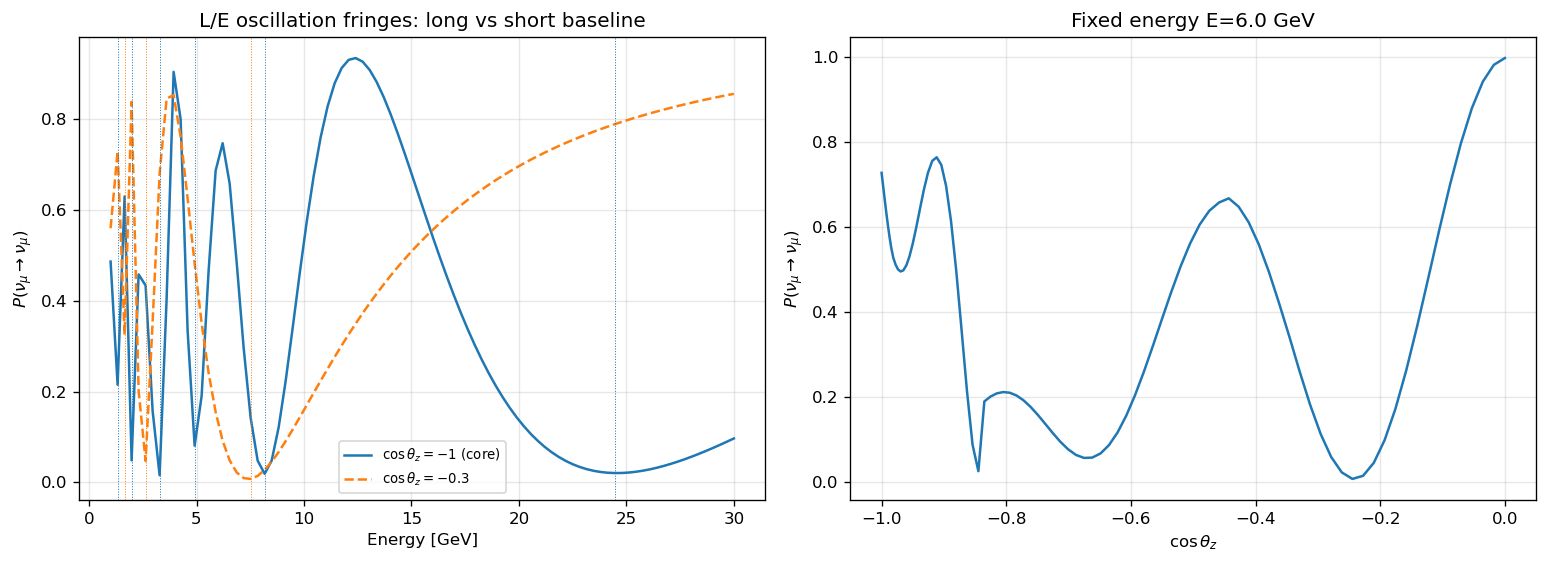

Number of L/E fringe minima, cos(theta_z)=-1   : 6
Number of L/E fringe minima, cos(theta_z)=-0.3 : 3
Resonance energy at cos(theta_z)=-1 : E~3.28 GeV, P_min=0.0155


In [50]:
def find_local_minima(P_1d, *, threshold=0.7):
    idx = [i for i in range(1, len(P_1d) - 1)
           if P_1d[i] < P_1d[i - 1] and P_1d[i] < P_1d[i + 1] and P_1d[i] < threshold]
    return idx


P_vs_E_core = to_numpy(oscillogram("numu", "numu", ENERGY_GRID_GEV, torch.tensor([180.0], dtype=DTYPE)))[:, 0]
P_vs_E_shallow = to_numpy(oscillogram("numu", "numu", ENERGY_GRID_GEV,
                                       torch.tensor([math.degrees(math.acos(-0.3))], dtype=DTYPE)))[:, 0]
P_vs_theta = to_numpy(oscillogram("numu", "numu", torch.tensor([PROBE_ENERGY_GEV], dtype=DTYPE), THETA_Z_GRID_DEG))[0, :]

minima_core = find_local_minima(P_vs_E_core)
minima_shallow = find_local_minima(P_vs_E_shallow)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
axes[0].plot(to_numpy(ENERGY_GRID_GEV), P_vs_E_core, label=r"$\cos\theta_z=-1$ (core)")
axes[0].plot(to_numpy(ENERGY_GRID_GEV), P_vs_E_shallow, label=r"$\cos\theta_z=-0.3$", ls="--")
for i in minima_core:
    axes[0].axvline(float(ENERGY_GRID_GEV[i]), color="C0", lw=0.6, ls=":")
for i in minima_shallow:
    axes[0].axvline(float(ENERGY_GRID_GEV[i]), color="C1", lw=0.6, ls=":")
axes[0].set_xlabel("Energy [GeV]")
axes[0].set_ylabel(r"$P(\nu_\mu\to\nu_\mu)$")
axes[0].set_title("L/E oscillation fringes: long vs short baseline")
axes[0].legend(fontsize=8)

axes[1].plot(cos_theta_z_grid, P_vs_theta)
axes[1].set_xlabel(r"$\cos\theta_z$")
axes[1].set_ylabel(r"$P(\nu_\mu\to\nu_\mu)$")
axes[1].set_title(f"Fixed energy E={PROBE_ENERGY_GEV:.1f} GeV")
fig.tight_layout()
save_and_show("oscillogram_cross_sections.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

E_min_idx = int(np.argmin(P_vs_E_core))
print(f"Number of L/E fringe minima, cos(theta_z)=-1   : {len(minima_core)}")
print(f"Number of L/E fringe minima, cos(theta_z)=-0.3 : {len(minima_shallow)}")
print(f"Resonance energy at cos(theta_z)=-1 : E~{float(ENERGY_GRID_GEV[E_min_idx]):.2f} GeV, P_min={P_vs_E_core[E_min_idx]:.4f}")

## 7. Summary

In [51]:
print("Summary -- Atmospheric neutrino oscillogram")
print("-" * 60)
print(f"Grid: E in [{float(ENERGY_GRID_GEV.min()):.1f}, {float(ENERGY_GRID_GEV.max()):.1f}] GeV, "
      f"cos(theta_z) in [{cos_theta_z_grid.min():.2f}, {cos_theta_z_grid.max():.2f}]")
print(f"min P(numu->numu) over the grid : {P_numu_numu.min():.4f}")
print(f"max P(numu->nue) over the grid  : {P_numu_nue.max():.4f}")
print(f"L/E fringe minima at cos(theta_z)=-1, -0.3 : {len(minima_core)}, {len(minima_shallow)}")
print(f"Resonance energy at cos(theta_z)=-1 : E~{float(ENERGY_GRID_GEV[E_min_idx]):.2f} GeV")

Summary -- Atmospheric neutrino oscillogram
------------------------------------------------------------
Grid: E in [1.0, 30.0] GeV, cos(theta_z) in [-1.00, 0.00]
min P(numu->numu) over the grid : 0.0001
max P(numu->nue) over the grid  : 0.5904
L/E fringe minima at cos(theta_z)=-1, -0.3 : 6, 3
Resonance energy at cos(theta_z)=-1 : E~3.28 GeV
